# Diabetes Multistage Prediction
### Stage 1: Risk Screening (Low Risk / High Risk)
### Stage 2: Clinical Classification (Non-diabetic / Prediabetic / Diabetic)

This notebook trains and compares 3 algorithms (Logistic Regression, Random Forest, KNN) for each stage.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from imblearn.over_sampling import SMOTE
import joblib
import os

os.makedirs("models", exist_ok=True)

## 1. Load Data

In [24]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
print(df.shape)
df.head()

(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [25]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

## 2. Quick EDA
Checking class balance and category values before doing anything else.
-looking at your data before touching it (how many rows, how imbalanced, what values exist)

diabetes
0    91500
1     8500
Name: count, dtype: int64
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


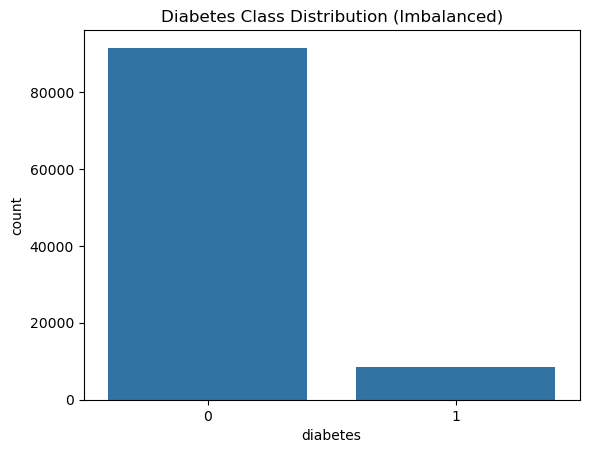

In [26]:
print(df['diabetes'].value_counts())
print(df['diabetes'].value_counts(normalize=True) * 100)

sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Class Distribution (Imbalanced)")
plt.show()

In [27]:
print(df['gender'].unique())
print(df['smoking_history'].unique())

['Female' 'Male' 'Other']
['never' 'No Info' 'current' 'former' 'ever' 'not current']


## 3. Preprocessing

- Encode `gender` and `smoking_history` (categorical -> numeric)
- Add a `bmi_category` feature (WHO categories) — extra engineered feature since we didn't collect new data
- Derive the Stage 2 label using ADA (American Diabetes Association) clinical thresholds:
  - **Diabetic**: HbA1c >= 6.5 OR glucose >= 126
  - **Prediabetic**: HbA1c 5.7-6.4 OR glucose 100-125
  - **Non-diabetic**: below both


In [28]:
# Encode categorical columns
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

df['gender_enc'] = le_gender.fit_transform(df['gender'])
df['smoking_enc'] = le_smoking.fit_transform(df['smoking_history'])

print(dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print(dict(zip(le_smoking.classes_, le_smoking.transform(le_smoking.classes_))))

{'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
{'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current': np.int64(5)}


In [29]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 0  # underweight
    elif bmi < 25:
        return 1  # normal
    elif bmi < 30:
        return 2  # overweight
    else:
        return 3  # obese

df['bmi_category'] = df['bmi'].apply(bmi_category)


In [30]:
def derive_stage2_label(row):
    hba1c = row['HbA1c_level']
    glucose = row['blood_glucose_level']
    if hba1c >= 6.5 or glucose >= 126:
        return 2  # Diabetic
    elif (5.7 <= hba1c < 6.5) or (100 <= glucose < 126):
        return 1  # Prediabetic
    else:
        return 0  # Non-diabetic

df['stage2_label'] = df.apply(derive_stage2_label, axis=1)
df['stage2_label'].value_counts()

stage2_label
2    76716
1    14539
0     8745
Name: count, dtype: int64

## 4. Stage 1: Risk Screening

**Features used (no lab tests):** gender, age, hypertension, heart_disease, smoking_history, bmi
**Target:** `diabetes` (0 = Low Risk, 1 = High Risk)

We handle class imbalance with SMOTE on the training set only.

In [31]:
stage1_features = ['gender_enc', 'age', 'hypertension', 'heart_disease', 'smoking_enc', 'bmi', 'bmi_category']
X1 = df[stage1_features]
y1 = df['diabetes']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.3, stratify=y1, random_state=42
)

# Scale numeric features
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

# Balance training data only
smote1 = SMOTE(random_state=42)
X1_train_bal, y1_train_bal = smote1.fit_resample(X1_train_scaled, y1_train)

print("Before SMOTE:", y1_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y1_train_bal).value_counts().to_dict())

Before SMOTE: {0: 64050, 1: 5950}
After SMOTE: {0: 64050, 1: 64050}


In [32]:
stage1_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}

stage1_results = {}

for name, model in stage1_models.items():
    model.fit(X1_train_bal, y1_train_bal)
    y1_pred = model.predict(X1_test_scaled)
    f1 = f1_score(y1_test, y1_pred)
    stage1_results[name] = f1
    print(f"\n===== {name} (Stage 1) =====")
    print(classification_report(y1_test, y1_pred, target_names=["Low Risk", "High Risk"]))


===== Logistic Regression (Stage 1) =====
              precision    recall  f1-score   support

    Low Risk       0.97      0.73      0.83     27450
   High Risk       0.21      0.78      0.33      2550

    accuracy                           0.73     30000
   macro avg       0.59      0.75      0.58     30000
weighted avg       0.91      0.73      0.79     30000


===== Random Forest (Stage 1) =====
              precision    recall  f1-score   support

    Low Risk       0.94      0.88      0.91     27450
   High Risk       0.23      0.38      0.29      2550

    accuracy                           0.84     30000
   macro avg       0.59      0.63      0.60     30000
weighted avg       0.88      0.84      0.86     30000


===== KNN (Stage 1) =====
              precision    recall  f1-score   support

    Low Risk       0.95      0.81      0.87     27450
   High Risk       0.21      0.54      0.30      2550

    accuracy                           0.79     30000
   macro avg       0.

Best Stage 1 model (by F1): Logistic Regression


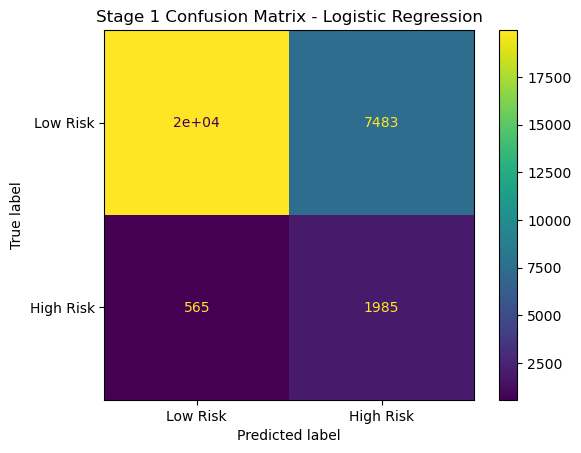

In [33]:
best_stage1_name = max(stage1_results, key=stage1_results.get)
best_stage1_model = stage1_models[best_stage1_name]
print("Best Stage 1 model (by F1):", best_stage1_name)

cm = confusion_matrix(y1_test, best_stage1_model.predict(X1_test_scaled))
ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"]).plot()
plt.title(f"Stage 1 Confusion Matrix - {best_stage1_name}")
plt.show()

## 4b. Compare Actual vs Predicted (Stage 1 Test Data)
This table shows real rows from the test set: what the true answer was vs what the best model guessed.

In [34]:
comparison1 = X1_test.copy()
comparison1['Actual'] = y1_test.map({0: "Low Risk", 1: "High Risk"})
comparison1['Predicted'] = pd.Series(
    best_stage1_model.predict(X1_test_scaled), index=X1_test.index
).map({0: "Low Risk", 1: "High Risk"})
comparison1['Correct?'] = comparison1['Actual'] == comparison1['Predicted']

comparison1.head(15)

,gender_enc,age,hypertension,heart_disease,smoking_enc,bmi,bmi_category,Actual,Predicted,Correct?
99961,1,38.00,0,0,4,27.63,2,Low Risk,Low Risk,True
28353,0,39.00,0,0,5,35.64,3,Low Risk,Low Risk,True
82494,0,34.00,0,0,5,27.32,2,Low Risk,Low Risk,True
78287,0,43.00,0,0,4,27.32,2,Low Risk,Low Risk,True
17812,0,62.00,0,0,4,37.17,3,Low Risk,High Risk,False
23320,0,57.00,0,0,0,33.53,3,Low Risk,High Risk,False
27015,0,29.00,0,0,1,38.66,3,Low Risk,Low Risk,True
25271,0,80.00,0,0,5,27.32,2,Low Risk,High Risk,False
1774,1,67.00,1,0,3,32.04,3,Low Risk,High Risk,False
4808,1,49.00,0,0,2,30.42,3,Low Risk,Low Risk,True


In [35]:
print("Out of", len(comparison1), "test rows:")
print("Correct predictions:", comparison1['Correct?'].sum())
print("Wrong predictions:", (~comparison1['Correct?']).sum())
print("Accuracy on test data:", round(comparison1['Correct?'].mean() * 100, 2), "%")

Out of 30000 test rows:
Correct predictions: 21952
Wrong predictions: 8048
Accuracy on test data: 73.17 %


## 5. Stage 2: Clinical Classification

**Features used:** Stage 1 features + HbA1c_level + blood_glucose_level
**Target:** derived `stage2_label` (0=Non-diabetic, 1=Prediabetic, 2=Diabetic)

In [36]:
stage2_features = stage1_features + ['HbA1c_level', 'blood_glucose_level']
X2 = df[stage2_features]
y2 = df['stage2_label']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, stratify=y2, random_state=42
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

smote2 = SMOTE(random_state=42)
X2_train_bal, y2_train_bal = smote2.fit_resample(X2_train_scaled, y2_train)

print("Before SMOTE:", y2_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y2_train_bal).value_counts().to_dict())

Before SMOTE: {2: 53701, 1: 10177, 0: 6122}
After SMOTE: {1: 53701, 2: 53701, 0: 53701}


In [37]:
stage2_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}

stage2_results = {}
labels2 = ["Non-diabetic", "Prediabetic", "Diabetic"]

for name, model in stage2_models.items():
    model.fit(X2_train_bal, y2_train_bal)
    y2_pred = model.predict(X2_test_scaled)
    f1 = f1_score(y2_test, y2_pred, average='macro')
    stage2_results[name] = f1
    print(f"\n===== {name} (Stage 2) =====")
    print(classification_report(y2_test, y2_pred, target_names=labels2))


===== Logistic Regression (Stage 2) =====
              precision    recall  f1-score   support

Non-diabetic       0.86      0.88      0.87      2623
 Prediabetic       0.71      0.91      0.80      4362
    Diabetic       1.00      0.94      0.97     23015

    accuracy                           0.93     30000
   macro avg       0.86      0.91      0.88     30000
weighted avg       0.95      0.93      0.94     30000


===== Random Forest (Stage 2) =====
              precision    recall  f1-score   support

Non-diabetic       1.00      1.00      1.00      2623
 Prediabetic       1.00      1.00      1.00      4362
    Diabetic       1.00      1.00      1.00     23015

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000


===== KNN (Stage 2) =====
              precision    recall  f1-score   support

Non-diabetic       0.92      0.98      0.95      2623
 Prediabetic       0.9

Best Stage 2 model (by macro F1): Random Forest


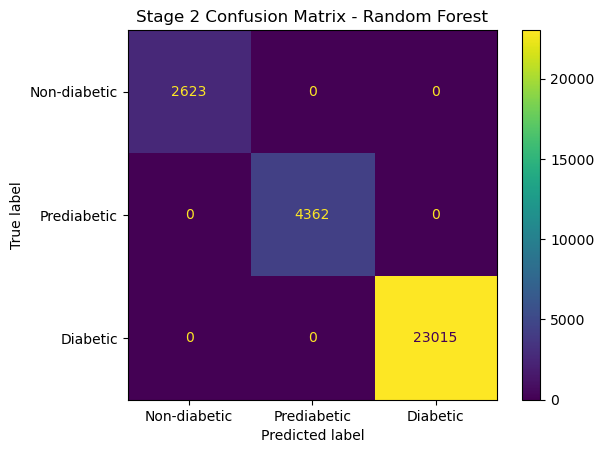

In [38]:
best_stage2_name = max(stage2_results, key=stage2_results.get)
best_stage2_model = stage2_models[best_stage2_name]
print("Best Stage 2 model (by macro F1):", best_stage2_name)

cm2 = confusion_matrix(y2_test, best_stage2_model.predict(X2_test_scaled))
ConfusionMatrixDisplay(cm2, display_labels=labels2).plot()
plt.title(f"Stage 2 Confusion Matrix - {best_stage2_name}")
plt.show()

## 6. Model Comparison Summary

In [39]:
summary = pd.DataFrame({
    "Stage 1 F1": pd.Series(stage1_results),
    "Stage 2 Macro F1": pd.Series(stage2_results),
})
summary

,Stage 1 F1,Stage 2 Macro F1
Logistic Regression,0.330338,0.878839
Random Forest,0.288100,1.000000
KNN,0.302792,0.958456


## 7. Save Models

These saved files are what the Streamlit app will load later — no retraining needed inside the app.

In [40]:
joblib.dump(best_stage1_model, "models/stage1_model.pkl")
joblib.dump(best_stage2_model, "models/stage2_model.pkl")
joblib.dump(scaler1, "models/stage1_scaler.pkl")
joblib.dump(scaler2, "models/stage2_scaler.pkl")
joblib.dump(le_gender, "models/le_gender.pkl")
joblib.dump(le_smoking, "models/le_smoking.pkl")

print("Saved:")
print("- Stage 1 model:", best_stage1_name)
print("- Stage 2 model:", best_stage2_name)

Saved:
- Stage 1 model: Logistic Regression
- Stage 2 model: Random Forest


## 8. Ablation Study: Full Features vs Reduced Features (Same Target)

This section directly answers: **"If we remove HbA1c and glucose, how much accuracy do we actually lose?"**

Unlike Stage 1 vs Stage 2 (which predict different targets), this comparison keeps the **target identical** — `diabetes` (0/1) — and only changes the **input features**. This makes it a fair, controlled comparison, isolating the effect of removing lab-based features.

- **Full Features**: all 7 Stage 1 features + HbA1c_level + blood_glucose_level
- **Reduced Features**: only the 7 Stage 1 features (no lab data)

Both use the exact same train/test rows, so the only thing that changes is which columns the model can see.

In [41]:
from sklearn.metrics import accuracy_score

# Same target for both — a fair, controlled comparison
target = df['diabetes']

reduced_features = ['gender_enc', 'age', 'hypertension', 'heart_disease', 'smoking_enc', 'bmi', 'bmi_category']
full_features = reduced_features + ['HbA1c_level', 'blood_glucose_level']

# Use the SAME split (same rows) for both feature sets, so the comparison is fair
train_idx, test_idx = train_test_split(
    df.index, test_size=0.3, stratify=target, random_state=42
)

In [42]:
def train_and_evaluate(feature_list, label):
    X = df[feature_list]
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = target.loc[train_idx], target.loc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

    results = {}
    algorithms = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=7),
    }
    print(f"\n========== {label} ==========")
    for name, model in algorithms.items():
        model.fit(X_train_bal, y_train_bal)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        results[name] = {"Accuracy": acc, "F1 (diabetes=1)": f1}
        print(f"{name:22s} Accuracy: {acc:.3f}   F1: {f1:.3f}")
    return results

full_results = train_and_evaluate(full_features, "FULL FEATURES (with HbA1c & glucose)")
reduced_results = train_and_evaluate(reduced_features, "REDUCED FEATURES (without HbA1c & glucose)")


========== FULL FEATURES (with HbA1c & glucose) ==========
Logistic Regression    Accuracy: 0.889   F1: 0.575
Random Forest          Accuracy: 0.962   F1: 0.769
KNN                    Accuracy: 0.907   F1: 0.601

========== REDUCED FEATURES (without HbA1c & glucose) ==========
Logistic Regression    Accuracy: 0.732   F1: 0.330
Random Forest          Accuracy: 0.841   F1: 0.288
KNN                    Accuracy: 0.787   F1: 0.303


In [43]:
ablation_df = pd.DataFrame({
    "Full Features - F1": {k: v["F1 (diabetes=1)"] for k, v in full_results.items()},
    "Reduced Features - F1": {k: v["F1 (diabetes=1)"] for k, v in reduced_results.items()},
})
ablation_df["Drop in F1"] = ablation_df["Full Features - F1"] - ablation_df["Reduced Features - F1"]
ablation_df["% Drop"] = (ablation_df["Drop in F1"] / ablation_df["Full Features - F1"] * 100).round(1)
ablation_df

,Full Features - F1,Reduced Features - F1,Drop in F1,% Drop
Logistic Regression,0.575125,0.330338,0.244787,42.6
Random Forest,0.768537,0.288100,0.480437,62.5
KNN,0.601429,0.302792,0.298636,49.7


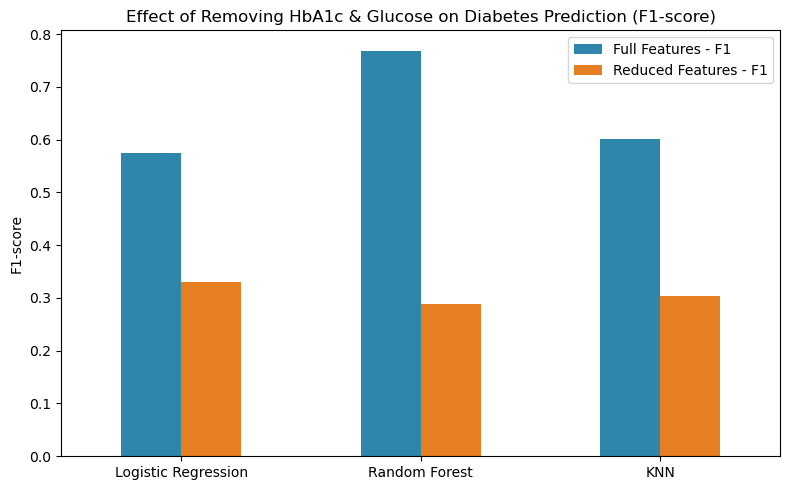

In [44]:
ablation_df[["Full Features - F1", "Reduced Features - F1"]].plot(
    kind="bar", figsize=(8, 5), color=["#2E86AB", "#E67E22"]
)
plt.title("Effect of Removing HbA1c & Glucose on Diabetes Prediction (F1-score)")
plt.ylabel("F1-score")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Interpretation

- If the F1-score drop is **small**, it means the reduced feature set (Stage 1) still captures most of the predictive signal, and skipping the lab test doesn't cost much accuracy.
- If the drop is **large**, it confirms that HbA1c and glucose carry information the other features can't replace, justifying why Stage 2 (with lab data) is still necessary for a reliable diagnosis.

This result should be reported alongside the actual numbers from the table above — write the real percentage drop you see when you run this notebook, since it directly answers whether reduced-feature screening is a viable substitute for full lab-based testing.